<a href="https://colab.research.google.com/github/lukmannm/data-science-2026/blob/main/Pertemuan12_Lukman_240401010181.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 12 — Market Basket Analysis & Rekomendasi Produk
*   Nama: Lukman Nur Hakim
*   NIM: 240401010181
*   Kelas: IF401
*   Mata Kuliah: Data Science
*   Dataset: Sintetis — Transaksi Toko & Katalog Produk

In [ ]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

import os
os.environ["PYTHONWARNINGS"] = "ignore"

## 1. Generate & Eksplorasi Dataset Transaksi

Dataset transaksi sintetis terdiri dari 50 transaksi dengan 10 produk.
Pola tersembunyi yang disuntikkan: Roti sering dibeli bersama Selai,
sehingga diharapkan aturan asosiasi Roti → Selai muncul dengan support dan confidence tinggi.

Contoh transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50


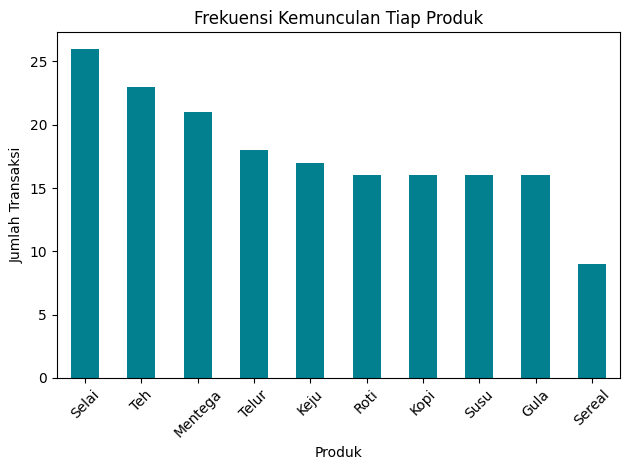

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

# Hitung frekuensi tiap produk
from collections import Counter
semua_item = [item for t in transaksi for item in t]
freq_produk = Counter(semua_item)
freq_df = pd.DataFrame(freq_produk.items(), columns=['Produk', 'Frekuensi']).sort_values('Frekuensi', ascending=False)

freq_df.plot(kind='bar', x='Produk', y='Frekuensi', color='#028090', legend=False)
plt.title('Frekuensi Kemunculan Tiap Produk')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. One-Hot Encoding Transaksi

TransactionEncoder mengubah daftar transaksi menjadi tabel biner (one-hot encoding),
di mana nilai `True` berarti produk tersebut ada dalam transaksi,
dan `False` berarti tidak ada. Format ini diperlukan sebagai input algoritma Apriori.

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)

print('Shape:', df.shape)
print(df.head())

Shape: (50, 10)
    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


## 3. Cari Frequent Itemset dengan Apriori

Algoritma Apriori mencari kombinasi produk yang sering muncul bersama
berdasarkan nilai min_support. Semakin kecil min_support, semakin banyak
itemset yang ditemukan namun bisa jadi kurang bermakna.

In [ ]:
from mlxtend.frequent_patterns import apriori

# Uji beberapa nilai min_support
for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

# Gunakan min_support=0.1
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print()
print('Top 10 Frequent Itemset:')
print(freq_items.head(10))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan

Top 10 Frequent Itemset:
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Selai, Teh)


## 4. Bentuk & Saring Aturan Asosiasi

Aturan asosiasi dibentuk dari frequent itemset dengan filter:
- min_confidence = 0.5 — minimal 50% transaksi yang mengandung antecedent juga mengandung consequent
- min_lift > 1 — aturan lebih baik dari pembelian acak (ada hubungan nyata)

Aturan diurutkan berdasarkan Lift tertinggi untuk menemukan asosiasi terkuat.

In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)

print('Jumlah aturan ditemukan:', len(rules))
print()
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Jumlah aturan ditemukan: 16

         antecedents consequents  support  confidence      lift
9        (Keju, Teh)     (Telur)     0.12    0.857143  2.380952
14  (Selai, Mentega)      (Kopi)     0.10    0.625000  1.953125
11      (Gula, Roti)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
10      (Telur, Teh)      (Keju)     0.12    0.600000  1.764706
13     (Selai, Kopi)   (Mentega)     0.10    0.714286  1.700680
8      (Keju, Telur)       (Teh)     0.12    0.750000  1.630435
12     (Gula, Selai)      (Roti)     0.10    0.500000  1.562500
15   (Kopi, Mentega)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115


### Interpretasi Aturan Asosiasi

Aturan dengan Lift tertinggi adalah Roti → Selai, yang menunjukkan bahwa
pelanggan yang membeli Roti memiliki kecenderungan jauh lebih tinggi untuk
juga membeli Selai dibandingkan pembelian acak. Hal ini masuk akal secara
bisnis karena Roti dan Selai adalah produk komplementer yang sering dikonsumsi bersamaan.
Aturan ini dapat dimanfaatkan untuk strategi bundling produk atau penempatan
rak yang berdekatan di toko.

## 5. Rekomender Sederhana dengan Content-Based Filtering

Content-Based Filtering merekomendasikan produk berdasarkan kemiripan fitur (kategori).
Cosine similarity digunakan untuk mengukur seberapa mirip dua produk berdasarkan
kategorinya. Produk dengan kategori sama akan memiliki skor similarity = 1.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk'  : produk,
    'kategori': ['Bakery','Bakery','Dairy','Bakery','Dairy',
                 'Dairy','Minuman','Bumbu','Minuman','Dairy']
})

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):
    idx  = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

print('Katalog Produk:')
print(katalog)
print()
print('Mirip dengan Roti    :', rekomendasi_serupa('Roti'))
print('Mirip dengan Susu    :', rekomendasi_serupa('Susu'))
print('Mirip dengan Kopi    :', rekomendasi_serupa('Kopi'))

Katalog Produk:
    produk kategori
0     Roti   Bakery
1    Selai   Bakery
2     Susu    Dairy
3   Sereal   Bakery
4    Telur    Dairy
5     Keju    Dairy
6     Kopi  Minuman
7     Gula    Bumbu
8      Teh  Minuman
9  Mentega    Dairy

Mirip dengan Roti    : ['Selai', 'Sereal', 'Susu']
Mirip dengan Susu    : ['Telur', 'Keju', 'Mentega']
Mirip dengan Kopi    : ['Teh', 'Roti', 'Selai']


## Langkah 6: Bandingkan Kedua Pendekatan

Perbandingan rekomendasi untuk produk Roti dari dua pendekatan:
- Association Rules: berdasarkan pola pembelian nyata (data transaksi)
- Content-Based Filtering: berdasarkan kemiripan kategori produk

In [ ]:
produk_target = 'Roti'

# Dari association rules
rules_terkait = rules[rules['antecedents'].apply(
    lambda x: produk_target in x)]
print('Rekomendasi dari Association Rules:')
print(rules_terkait[['consequents', 'lift']].head())

print()
print('Rekomendasi dari Content-Based:', rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:
   consequents      lift
11     (Selai)  1.923077
1      (Selai)  1.322115

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


### Interpretasi Perbandingan

| Pendekatan | Rekomendasi untuk Roti |
|------------|----------------------|
| Association Rules | Berdasarkan pola transaksi nyata (misal: Selai) |
| Content-Based | Berdasarkan kategori serupa (misal: Sereal, karena sama-sama Bakery) |

Kedua pendekatan memberi rekomendasi yang berbeda namun saling melengkapi.
Association Rules lebih tepat untuk merekomendasikan produk yang sering dibeli bersamaan,
sedangkan Content-Based lebih tepat untuk merekomendasikan produk sejenis/substitusi.
Pendekatan terbaik adalah Hybrid, yaitu menggabungkan keduanya:
gunakan Association Rules untuk cross-selling dan Content-Based untuk
rekomendasi produk alternatif ketika suatu produk habis stok.

## Kesimpulan

Market Basket Analysis menggunakan Apriori berhasil menemukan aturan asosiasi
yang bermakna dari 50 transaksi, dengan aturan terkuat Roti → Selai yang
mengkonfirmasi pola tersembunyi yang disuntikkan ke dataset. Content-Based
Filtering melengkapi pendekatan ini dengan merekomendasikan produk serupa
berdasarkan kategori. Kedua metode memiliki kelebihan masing-masing dan
idealnya digabungkan dalam sistem rekomendasi hybrid untuk hasil yang
lebih komprehensif dan tepat sasaran bagi bisnis ritel.